In [ ]:
import subprocess, sys, warnings, itertools, math
warnings.filterwarnings("ignore")

import importlib.util
_needed = {"huggingface_hub": "huggingface_hub>=0.24", "pyarrow": "pyarrow",
           "pandas": "pandas", "sklearn": "scikit-learn",
           "matplotlib": "matplotlib", "scipy": "scipy"}
_missing = [pkg for mod, pkg in _needed.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print("installing:", ", ".join(_missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_missing], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from huggingface_hub import HfApi, hf_hub_download
from sklearn.metrics import roc_auc_score, cohen_kappa_score, average_precision_score
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

SEED = 0
rng_global = np.random.default_rng(SEED)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 100)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})

REPO = "Anthropic/claude-protein-binder-design"
BAR = "=" * 78

def head(n, title):
    prefix = f"{n}. " if str(n) else ""
    print(f"\n{BAR}\n  {prefix}{title}\n{BAR}")

head(1, "TABLE DISCOVERY")

api = HfApi()
repo_files = api.list_repo_files(REPO, repo_type="dataset")

TABLES = {}
for f in repo_files:
    if f.startswith("data/tables/") and f.endswith(".parquet"):
        key = f[len("data/tables/"): -len(".parquet")].replace("/", "_")
        TABLES[key] = f

print(f"Found {len(TABLES)} Parquet tables:")
for k in sorted(TABLES):
    print(f"   - {k:38s} {TABLES[k]}")

def load_table(name: str) -> pd.DataFrame:
    """Load a subset by its viewer name, with a datasets-library fallback."""
    if name in TABLES:
        return pd.read_parquet(hf_hub_download(REPO, TABLES[name], repo_type="dataset"))
    from datasets import load_dataset
    return load_dataset(REPO, name, split="full").to_pandas()

ds = load_table("design_summary")
print(f"\ndesign_summary: {ds.shape[0]:,} rows x {ds.shape[1]} columns")

In [ ]:
head(2, "SCHEMA + EVALUABLE SET")

CALLS = {"binder", "non_binder"}
tested = ds["adaptyv_binding"].isin(CALLS) | ds["twist_binding"].isin(CALLS)
ev = ds[tested].copy()
ev["y"] = ev["binder_final"].astype(int)

print(f"All designs               : {len(ds):,}")
print(f"Evaluable (>=1 vendor call): {len(ev):,}")
print(f"Confirmed binders          : {int(ev['y'].sum()):,}  "
      f"({100 * ev['y'].mean():.1f}% base rate)")
print(f"Never measured             : {len(ds) - len(ev):,}")

print("\nCategorical levels:")
for c in ["design_model", "campaign", "generator", "sequence_design_method", "vendor_agreement"]:
    vals = ds[c].astype(str).value_counts()
    print(f"  {c:24s} ({len(vals)}): {', '.join(vals.index[:6])}"
          + (" ..." if len(vals) > 6 else ""))

print(f"\nTargets ({ds['target'].nunique()}): {', '.join(sorted(ds['target'].unique()))}")
print(f"Binder length: {ds.binder_length.min()}-{ds.binder_length.max()} aa "
      f"(median {ds.binder_length.median():.0f})")

head(3, "HIT-RATE LANDSCAPE")

def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan, np.nan)
    p = k / n
    d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return p, max(0.0, c - h), min(1.0, c + h)

def rate_table(df, by):
    rows = []
    for key, g in df.groupby(by, dropna=False):
        p, lo, hi = wilson(int(g.y.sum()), len(g))
        rows.append({by: key, "n": len(g), "hits": int(g.y.sum()),
                     "rate": p, "lo": lo, "hi": hi})
    return pd.DataFrame(rows).sort_values("rate", ascending=False).reset_index(drop=True)

for dim in ["design_model", "campaign", "generator", "sequence_design_method"]:
    t = rate_table(ev, dim)
    print(f"\n--- hit rate by {dim} ---")
    print(t.to_string(index=False,
                      formatters={"rate": "{:.3f}".format, "lo": "{:.3f}".format, "hi": "{:.3f}".format}))

tt = rate_table(ev, "target")
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(tt.target, tt.rate, color="#4C72B0")
ax.errorbar(tt.target, tt.rate,
            yerr=[(tt.rate - tt.lo).clip(lower=0), (tt.hi - tt.rate).clip(lower=0)],
            fmt="none", ecolor="0.25", capsize=3, lw=1)
ax.axhline(ev.y.mean(), ls="--", c="crimson", lw=1, label=f"pooled {ev.y.mean():.2f}")
ax.set_ylabel("experimental hit rate"); ax.set_title("Hit rate by target (Wilson 95% CI)")
ax.tick_params(axis="x", rotation=55); ax.legend(); plt.tight_layout(); plt.show()

print("\nRead this plot as the dominant effect size in the dataset: target choice "
      "swamps generator choice. Any model comparison that does not stratify by "
      "target is mostly measuring which targets that model was pointed at.")

In [ ]:
head(4, "PER-PREDICTOR DISCRIMINATIVE POWER")

PREDICTORS = sorted({c[len("ipsae_min_"):] for c in ds.columns if c.startswith("ipsae_min_")})
print(f"Predictors ({len(PREDICTORS)}): {', '.join(PREDICTORS)}")

def auc_ci(y, s, n_boot=300, seed=SEED):
    s = np.asarray(s, dtype=float); y = np.asarray(y, dtype=int)
    m = ~np.isnan(s)
    y, s = y[m], s[m]
    if len(y) < 30 or len(np.unique(y)) < 2:
        return dict(auc=np.nan, lo=np.nan, hi=np.nan, n=len(y), ap=np.nan)
    base = roc_auc_score(y, s)
    ap = average_precision_score(y, s)
    rng = np.random.default_rng(seed)
    idx, boots = np.arange(len(y)), []
    for _ in range(n_boot):
        b = rng.choice(idx, len(idx), replace=True)
        if len(np.unique(y[b])) > 1:
            boots.append(roc_auc_score(y[b], s[b]))
    lo, hi = (np.percentile(boots, [2.5, 97.5]) if boots else (np.nan, np.nan))
    return dict(auc=base, lo=lo, hi=hi, n=len(y), ap=ap)

rows = []
for p in PREDICTORS:
    for metric in ["ipsae_min", "sc_dockq"]:
        col = f"{metric}_{p}"
        if col in ev.columns:
            r = auc_ci(ev.y, ev[col])
            rows.append({"predictor": p, "metric": metric, **r})

perf = pd.DataFrame(rows)
piv = perf.pivot(index="predictor", columns="metric", values="auc").sort_values("ipsae_min", ascending=False)
print("\nAUC vs experimental binder_final:")
print(perf.sort_values("auc", ascending=False).to_string(
    index=False, formatters={c: "{:.3f}".format for c in ["auc", "lo", "hi", "ap"]}))

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(piv)); w = 0.38
for i, (metric, colr) in enumerate([("ipsae_min", "#4C72B0"), ("sc_dockq", "#DD8452")]):
    sub = perf[perf.metric == metric].set_index("predictor").reindex(piv.index)
    lo_err = (sub.auc - sub.lo).clip(lower=0).fillna(0)
    hi_err = (sub.hi - sub.auc).clip(lower=0).fillna(0)
    ax.bar(x + (i - 0.5) * w, sub.auc, w, label=metric, color=colr)
    ax.errorbar(x + (i - 0.5) * w, sub.auc,
                yerr=[lo_err, hi_err], fmt="none", ecolor="0.3", capsize=2, lw=0.9)
ax.axhline(0.5, ls="--", c="crimson", lw=1)
ax.set_xticks(x); ax.set_xticklabels(piv.index, rotation=45, ha="right")
ax.set_ylabel("AUC"); ax.set_ylim(0.35, None)
ax.set_title("In-silico score vs wet-lab binding, by structure predictor")
ax.legend(); plt.tight_layout(); plt.show()

print("Interpretation: AUCs land well above chance but far below the ~0.9 you "
      "would need to trust a single filter. That gap is the entire practical "
      "reason this dataset exists.")

head(5, "CONSENSUS SCORING")

ips_cols = [f"ipsae_min_{p}" for p in PREDICTORS if f"ipsae_min_{p}" in ev.columns]
dq_cols = [f"sc_dockq_{p}" for p in PREDICTORS if f"sc_dockq_{p}" in ev.columns]

def pct_rank(df, cols):
    return df[cols].rank(pct=True, na_option="keep")

R_ips, R_dq = pct_rank(ev, ips_cols), pct_rank(ev, dq_cols)
ev["cons_ipsae"] = R_ips.mean(axis=1)
ev["cons_dockq"] = R_dq.mean(axis=1)
ev["cons_all"] = pd.concat([R_ips, R_dq], axis=1).mean(axis=1)
ev["cons_median"] = pd.concat([R_ips, R_dq], axis=1).median(axis=1)
ev["cons_min"] = pd.concat([R_ips, R_dq], axis=1).min(axis=1)
ev["cons_disagree"] = pd.concat([R_ips, R_dq], axis=1).std(axis=1)

best_single = perf.loc[perf.auc.idxmax()]
print(f"Best single column: {best_single.metric}_{best_single.predictor}  AUC={best_single.auc:.3f}")
print()
for name in ["cons_ipsae", "cons_dockq", "cons_all", "cons_median", "cons_min", "cons_disagree"]:
    r = auc_ci(ev.y, ev[name])
    print(f"  {name:16s} AUC={r['auc']:.3f}  [{r['lo']:.3f}, {r['hi']:.3f}]  AP={r['ap']:.3f}")

corr = ev[ips_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(corr.values, cmap="viridis", vmin=0, vmax=1)
lbl = [c.replace("ipsae_min_", "") for c in ips_cols]
ax.set_xticks(range(len(lbl))); ax.set_xticklabels(lbl, rotation=90)
ax.set_yticks(range(len(lbl))); ax.set_yticklabels(lbl)
ax.set_title("Spearman correlation between predictors (ipSAE)")
ax.grid(False); fig.colorbar(im, shrink=0.8); plt.tight_layout(); plt.show()

print("\nIf every off-diagonal cell were ~1.0 there would be no ensemble gain to "
      "harvest. The moderate correlations are why cons_all typically edges out "
      "the best single predictor — and why disagreement itself carries signal.")

In [ ]:
head(6, "BUDGET CURVES (precision@N)")

def budget_curve(df, score_col, max_n=400):
    d = df[[score_col, "y"]].dropna().sort_values(score_col, ascending=False)
    hits = d.y.values.cumsum()
    n = np.arange(1, len(d) + 1)
    k = min(max_n, len(d))
    return n[:k], (hits / n)[:k]

fig, ax = plt.subplots(figsize=(8, 4.4))
best_col = f"{best_single.metric}_{best_single.predictor}"
for col, lab, style in [(best_col, f"best single ({best_col})", "-"),
                        ("cons_all", "consensus (rank-avg, all)", "-"),
                        ("cons_min", "consensus (unanimity/min)", "--")]:
    n, prec = budget_curve(ev, col)
    ax.plot(n, prec, style, lw=1.8, label=lab)
ax.axhline(ev.y.mean(), ls=":", c="crimson", lw=1.4, label=f"random baseline ({ev.y.mean():.2f})")
ax.set_xlabel("designs ordered for wet-lab testing (N, best-first)")
ax.set_ylabel("hit rate among top N"); ax.set_title("How much does in-silico triage buy you?")
ax.legend(); plt.tight_layout(); plt.show()

print("Enrichment at small budgets:")
for N in [25, 50, 100, 200]:
    line = f"  N={N:4d} | random {ev.y.mean():.3f}"
    for col, lab in [(best_col, "best-single"), ("cons_all", "consensus")]:
        n, prec = budget_curve(ev, col, max_n=N)
        line += f" | {lab} {prec[-1]:.3f} ({prec[-1] / ev.y.mean():.2f}x)"
    print(line)

head(7, "VENDOR CONCORDANCE")

both = ev[ev.adaptyv_binding.isin(CALLS) & ev.twist_binding.isin(CALLS)]
ct = pd.crosstab(both.adaptyv_binding, both.twist_binding)
print(f"Designs with calls from BOTH vendors: {len(both):,}\n")
print(ct.to_string())

if len(both) > 10:
    kappa = cohen_kappa_score(both.adaptyv_binding, both.twist_binding)
    agree = (both.adaptyv_binding == both.twist_binding).mean()
    print(f"\nRaw agreement: {agree:.3f}   Cohen's kappa: {kappa:.3f}")
    print("Kappa well under 1.0 means part of the 'unpredictable' variance above "
          "is assay disagreement, not model failure.")

kd = ev[["adaptyv_kd_nM", "twist_kd_nM"]].dropna()
kd = kd[(kd > 0).all(axis=1)]
if len(kd) > 10:
    rho, pv = stats.spearmanr(kd.adaptyv_kd_nM, kd.twist_kd_nM)
    fig, ax = plt.subplots(figsize=(4.8, 4.6))
    ax.scatter(kd.adaptyv_kd_nM, kd.twist_kd_nM, s=16, alpha=0.6, c="#4C72B0", edgecolor="none")
    lims = [min(kd.min()) * 0.5, max(kd.max()) * 2]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Adaptyv KD (nM)"); ax.set_ylabel("Twist KD (nM)")
    ax.set_title(f"Cross-vendor KD, n={len(kd)}, Spearman rho={rho:.2f}")
    plt.tight_layout(); plt.show()
    med_ratio = np.median(kd.twist_kd_nM / kd.adaptyv_kd_nM)
    print(f"Median KD ratio (Twist/Adaptyv): {med_ratio:.2f}x  -> systematic format offset, "
          "so treat absolute KD across vendors as ordinal, not interchangeable.")

In [ ]:
head(8, "EXPRESSION CONFOUND")

if "twist_expression_mg_per_mL" in ev.columns:
    g = ev.dropna(subset=["twist_expression_mg_per_mL"])
    a = g.loc[g.y == 1, "twist_expression_mg_per_mL"]
    b = g.loc[g.y == 0, "twist_expression_mg_per_mL"]
    if len(a) > 5 and len(b) > 5:
        u, pv = stats.mannwhitneyu(a, b)
        print(f"Titer (mg/mL)  binders median {a.median():.2f} (n={len(a)})  |  "
              f"non-binders {b.median():.2f} (n={len(b)})   Mann-Whitney p={pv:.2e}")
    r = auc_ci(g.y, g.twist_expression_mg_per_mL)
    print(f"AUC of raw expression titer alone as a 'binder' predictor: {r['auc']:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
    axes[0].hist([b, a], bins=25, label=["non-binder", "binder"],
                 color=["#BBBBBB", "#4C72B0"], density=True)
    axes[0].set_xlabel("Twist titer (mg/mL)"); axes[0].set_ylabel("density"); axes[0].legend()
    axes[0].set_title("Expression by outcome")

    if "adaptyv_expression" in ev.columns:
        ex = ev.groupby(ev.adaptyv_expression.astype(str)).y.agg(["mean", "size"])
        ex = ex[ex["size"] >= 10].sort_values("mean")
        axes[1].barh(ex.index, ex["mean"], color="#DD8452")
        axes[1].set_xlabel("hit rate"); axes[1].set_title("Hit rate by Adaptyv expression class")
    plt.tight_layout(); plt.show()

print("\nTakeaway: if expression alone scores meaningfully above 0.5, then part of "
      "every AUC in section 4 is a solubility signal riding along. To isolate "
      "interface quality, re-run section 4 restricted to designs that expressed.")

expressed = ev[ev.adaptyv_expression.astype(str).isin(["medium", "high"])] if "adaptyv_expression" in ev.columns else ev
if len(expressed) > 100:
    r_all = auc_ci(ev.y, ev.cons_all)
    r_exp = auc_ci(expressed.y, expressed.cons_all)
    print(f"  consensus AUC, all evaluable   : {r_all['auc']:.3f} (n={r_all['n']})")
    print(f"  consensus AUC, expressed only  : {r_exp['auc']:.3f} (n={r_exp['n']})")

head(9, "EPITOPE CONVERGENCE")

def parse_epitope(s):
    if not isinstance(s, str) or not s.strip():
        return frozenset()
    out = set()
    for tok in s.split(";"):
        tok = tok.strip()
        if not tok:
            continue
        out.add(tok.split(":")[-1])
    return frozenset(out)

ev["epi"] = ev["epitope_residues"].apply(parse_epitope)

def mean_pairwise_jaccard(sets, max_pairs=4000, seed=SEED):
    sets = [s for s in sets if len(s) > 0]
    if len(sets) < 2:
        return np.nan
    pairs = list(itertools.combinations(range(len(sets)), 2))
    rng = np.random.default_rng(seed)
    if len(pairs) > max_pairs:
        pairs = [pairs[i] for i in rng.choice(len(pairs), max_pairs, replace=False)]
    vals = []
    for i, j in pairs:
        u = len(sets[i] | sets[j])
        vals.append(len(sets[i] & sets[j]) / u if u else 0.0)
    return float(np.mean(vals))

rows = []
for tgt, g in ev.groupby("target"):
    B = g.loc[g.y == 1, "epi"].tolist()
    N = g.loc[g.y == 0, "epi"].tolist()
    if len(B) >= 3 and len(N) >= 3:
        rows.append({"target": tgt, "n_bind": len(B), "n_non": len(N),
                     "J_binders": mean_pairwise_jaccard(B),
                     "J_nonbinders": mean_pairwise_jaccard(N)})
epi = pd.DataFrame(rows)
if len(epi):
    epi["delta"] = epi.J_binders - epi.J_nonbinders
    print(epi.sort_values("delta", ascending=False).to_string(
        index=False, formatters={c: "{:.3f}".format for c in ["J_binders", "J_nonbinders", "delta"]}))
    w = stats.wilcoxon(epi.J_binders, epi.J_nonbinders) if len(epi) >= 6 else None
    if w:
        print(f"\nPaired Wilcoxon across targets: p={w.pvalue:.4f}  "
              f"(binders more epitope-convergent than failures?)")

    tgt = epi.sort_values("n_bind", ascending=False).target.iloc[0]
    sub = ev[ev.target == tgt]
    freq_b = pd.Series([r for s in sub[sub.y == 1].epi for r in s]).value_counts()
    freq_n = pd.Series([r for s in sub[sub.y == 0].epi for r in s]).value_counts()
    top = freq_b.head(18).index
    fig, ax = plt.subplots(figsize=(9, 3.8))
    xx = np.arange(len(top))
    ax.bar(xx - 0.2, (freq_b.reindex(top).fillna(0) / max(1, (sub.y == 1).sum())), 0.4,
           label="binders", color="#4C72B0")
    ax.bar(xx + 0.2, (freq_n.reindex(top).fillna(0) / max(1, (sub.y == 0).sum())), 0.4,
           label="non-binders", color="#BBBBBB")
    ax.set_xticks(xx); ax.set_xticklabels(top, rotation=70, ha="right")
    ax.set_ylabel("fraction of designs contacting"); ax.set_title(f"Epitope usage on {tgt}")
    ax.legend(); plt.tight_layout(); plt.show()


  1. TABLE DISCOVERY


Found 19 Parquet tables:
   - adaptyv_fit_curves                     data/tables/adaptyv/fit_curves.parquet
   - adaptyv_fits_all_models                data/tables/adaptyv/fits_all_models.parquet
   - adaptyv_reads                          data/tables/adaptyv/reads.parquet
   - adaptyv_replicates                     data/tables/adaptyv/replicates.parquet
   - adaptyv_results                        data/tables/adaptyv/results.parquet
   - column_dictionary                      data/tables/column_dictionary.parquet
   - design_summary                         data/tables/design_summary.parquet
   - insilico_cofold_predictions            data/tables/insilico/cofold_predictions.parquet
   - insilico_epitope_residue_contacts      data/tables/insilico/epitope_residue_contacts.parquet
   - insilico_provenance_steps              data/tables/insilico/provenance_steps.parquet
   - insilico_provenance_summary            data/tables/insilico/provenance_summary.parquet
   - insilico_target_construct

data/tables/design_summary.parquet: reconstructing file:   0%|          |  0.00B /  518kB            

data/tables/design_summary.parquet: downloading bytes:           |  0.00B            


design_summary: 1,440 rows x 65 columns

  2. SCHEMA + EVALUABLE SET
All designs               : 1,440
Evaluable (>=1 vendor call): 1,314
Confirmed binders          : 354  (26.9% base rate)
Never measured             : 126

Categorical levels:
  design_model             (2): Mythos Preview, Opus 4.8
  campaign                 (3): multi_target, single_target, single_target_supplementary
  generator                (10): PXDesign, RFdiffusion3, Genie3, BoltzGen, FreeBindCraft (BindCraft), RFdiffusion ...
  sequence_design_method   (4): SolubleMPNN, Caliby (SolubleCaliby), designed jointly by the structure model (native co-design), ProteinMPNN
  vendor_agreement         (8): neither_bind, both_bind, None, adaptyv_only_bind, twist_only_bind, adaptyv_only_tested ...

Targets (16): 15-PGDH, BBF-14, BHRF1, Cas9, EGFR, IL-7Ra, Latent GDF-8, MBP, Mature GDF-8, Nipah-G, PD-L1, RBX1, TNFa, TREM2, TrkA, VEGF-A
Binder length: 50-120 aa (median 80)

  3. HIT-RATE LANDSCAPE

--- hit rate by design_m

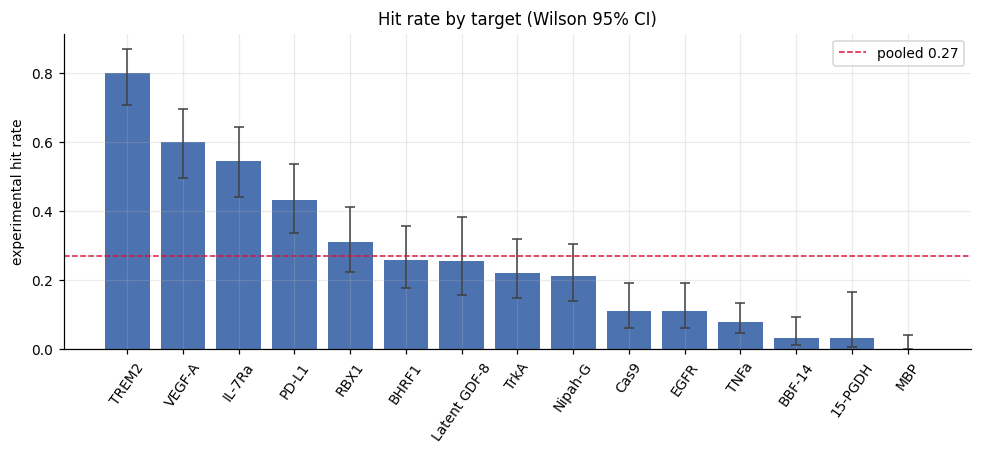


Read this plot as the dominant effect size in the dataset: target choice swamps generator choice. Any model comparison that does not stratify by target is mostly measuring which targets that model was pointed at.

  4. PER-PREDICTOR DISCRIMINATIVE POWER
Predictors (10): af3of3, afm3, boltz2, chai1, ef2fast, ef2full, odde, of3, ptxv2, rf3

AUC vs experimental binder_final:
predictor    metric   auc    lo    hi    n    ap
    chai1 ipsae_min 0.744 0.711 0.777 1314 0.462
      of3 ipsae_min 0.741 0.714 0.767 1314 0.468
     afm3 ipsae_min 0.732 0.702 0.761 1224 0.454
  ef2full ipsae_min 0.720 0.691 0.747 1314 0.408
  ef2fast ipsae_min 0.719 0.691 0.747 1314 0.401
   af3of3 ipsae_min 0.709 0.679 0.737 1314 0.405
     odde ipsae_min 0.696 0.666 0.723 1314 0.391
    ptxv2 ipsae_min 0.692 0.661 0.722 1314 0.381
   boltz2 ipsae_min 0.692 0.665 0.721 1314 0.389
      rf3 ipsae_min 0.688 0.652 0.713 1314 0.413
     afm3  sc_dockq 0.688 0.654 0.717 1086 0.424
   boltz2  sc_dockq 0.681 0.647 0.71

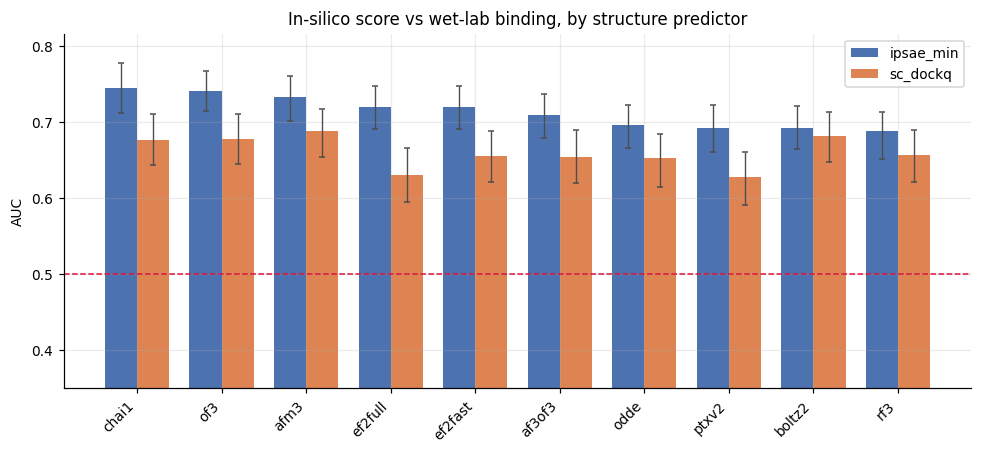

Interpretation: AUCs land well above chance but far below the ~0.9 you would need to trust a single filter. That gap is the entire practical reason this dataset exists.

  5. CONSENSUS SCORING
Best single column: ipsae_min_chai1  AUC=0.744

  cons_ipsae       AUC=0.750  [0.722, 0.775]  AP=0.463
  cons_dockq       AUC=0.690  [0.658, 0.722]  AP=0.425
  cons_all         AUC=0.738  [0.709, 0.764]  AP=0.450
  cons_median      AUC=0.720  [0.692, 0.747]  AP=0.423
  cons_min         AUC=0.752  [0.726, 0.778]  AP=0.487
  cons_disagree    AUC=0.470  [0.436, 0.502]  AP=0.252


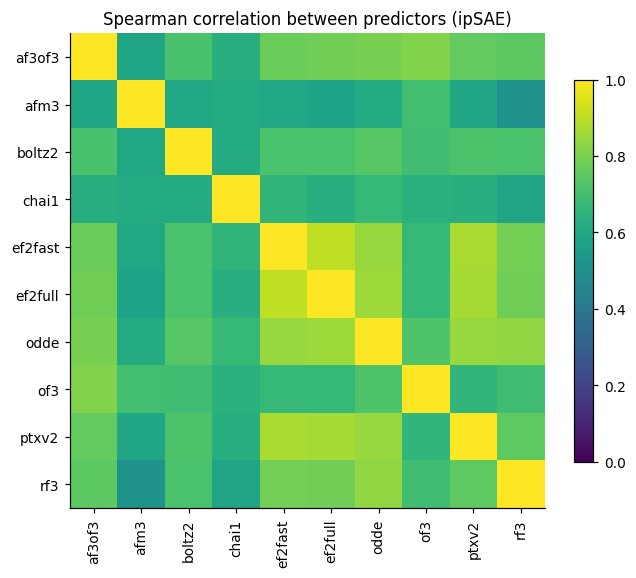


If every off-diagonal cell were ~1.0 there would be no ensemble gain to harvest. The moderate correlations are why cons_all typically edges out the best single predictor — and why disagreement itself carries signal.

  6. BUDGET CURVES (precision@N)


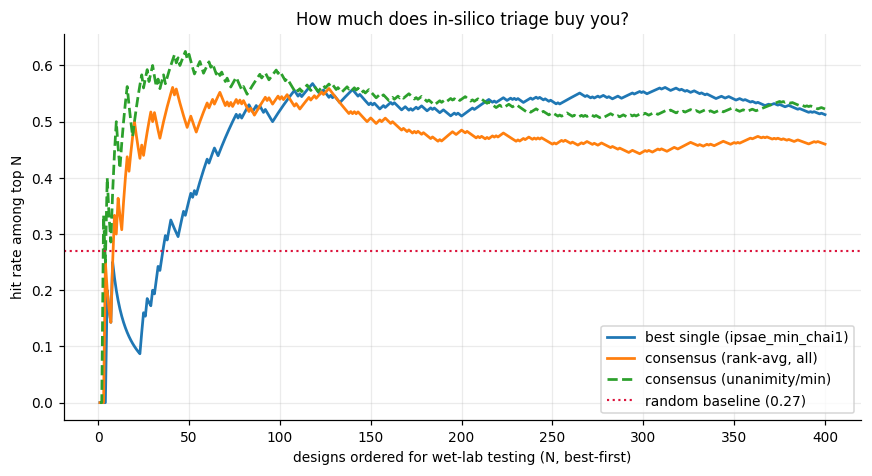

Enrichment at small budgets:
  N=  25 | random 0.269 | best-single 0.160 (0.59x) | consensus 0.440 (1.63x)
  N=  50 | random 0.269 | best-single 0.360 (1.34x) | consensus 0.500 (1.86x)
  N= 100 | random 0.269 | best-single 0.520 (1.93x) | consensus 0.540 (2.00x)
  N= 200 | random 0.269 | best-single 0.510 (1.89x) | consensus 0.485 (1.80x)

  7. VENDOR CONCORDANCE
Designs with calls from BOTH vendors: 1,175

twist_binding    binder  non_binder
adaptyv_binding                    
binder              253          69
non_binder           56         797

Raw agreement: 0.894   Cohen's kappa: 0.729
Kappa well under 1.0 means part of the 'unpredictable' variance above is assay disagreement, not model failure.


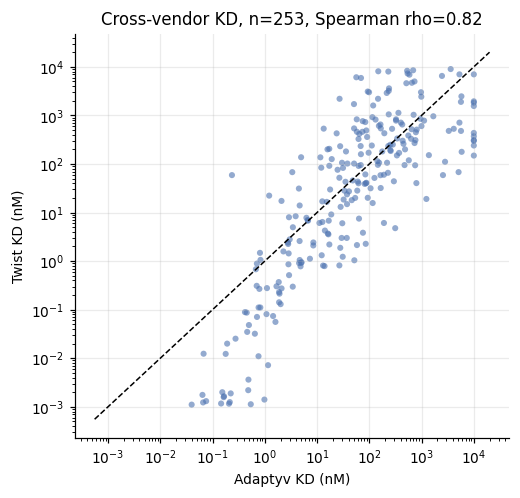

Median KD ratio (Twist/Adaptyv): 0.55x  -> systematic format offset, so treat absolute KD across vendors as ordinal, not interchangeable.

  8. EXPRESSION CONFOUND
Titer (mg/mL)  binders median 0.86 (n=340)  |  non-binders 0.77 (n=914)   Mann-Whitney p=1.75e-01
AUC of raw expression titer alone as a 'binder' predictor: 0.525


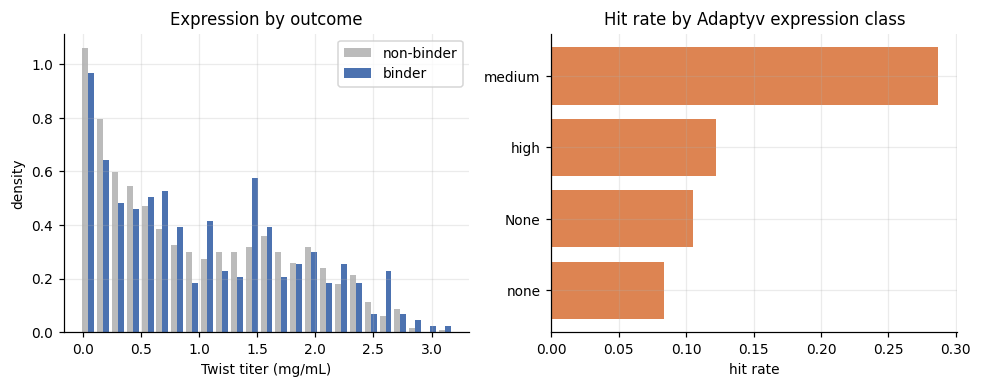


Takeaway: if expression alone scores meaningfully above 0.5, then part of every AUC in section 4 is a solubility signal riding along. To isolate interface quality, re-run section 4 restricted to designs that expressed.
  consensus AUC, all evaluable   : 0.738 (n=1314)
  consensus AUC, expressed only  : 0.749 (n=1234)

  9. EPITOPE CONVERGENCE
      target  n_bind  n_non J_binders J_nonbinders  delta
        TNFa      12    138     0.703        0.318  0.385
        EGFR      10     80     0.470        0.336  0.135
     Nipah-G      19     71     0.293        0.201  0.092
       BHRF1      23     66     0.561        0.490  0.071
       TREM2      72     18     0.494        0.428  0.066
      IL-7Ra      49     41     0.475        0.415  0.060
      VEGF-A      54     36     0.408        0.377  0.031
        TrkA      20     70     0.417        0.410  0.007
Latent GDF-8      14     41     0.290        0.291 -0.002
       PD-L1      39     51     0.529        0.559 -0.030
      BBF-14    

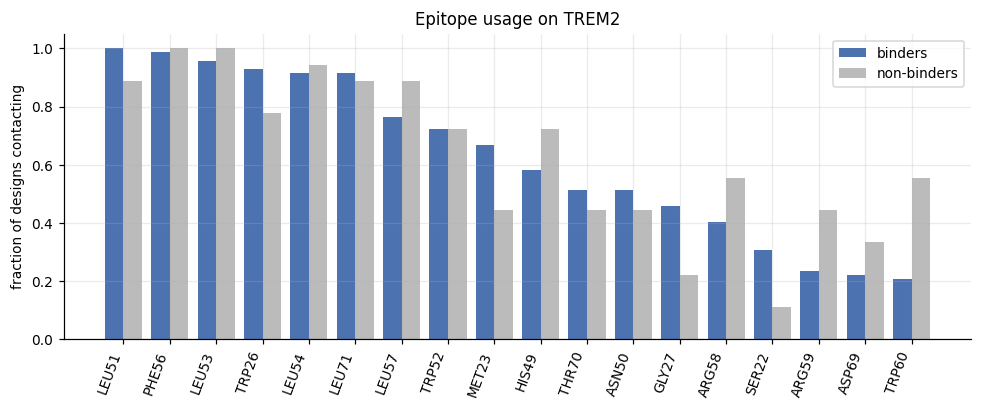


  10. MODELLING WITH HONEST CROSS-VALIDATION
feature set                   random 5-fold    grouped-by-target
------------------------------------------------------------------
in-silico only           0.828 +/- 0.008   0.674 +/- 0.027
sequence only            0.710 +/- 0.012   0.508 +/- 0.052
in-silico + sequence     0.852 +/- 0.009   0.708 +/- 0.053

Random-CV minus grouped-CV for the full feature set: +0.144
That gap is leakage: features that encode target identity (epitope size, length priors, generator habits) let a randomly-split model recover the per-target base rate instead of learning what makes a binder. Report the grouped number; the random one is what a target-blind reviewer will catch.

Control - target one-hot ONLY, random CV: AUC=0.807 (pure base-rate memorisation, zero design signal).


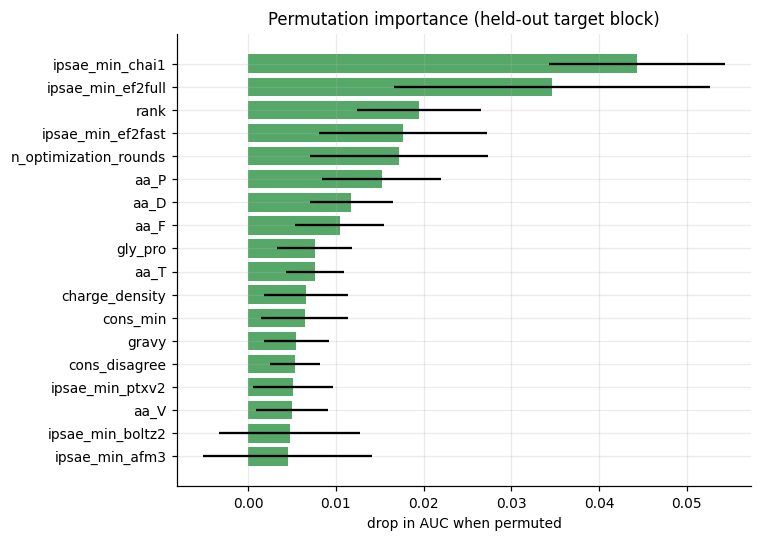


  SUMMARY

 Evaluable designs        : 1,314   base hit rate 0.269
 Best single in-silico    : ipsae_min_chai1  AUC 0.744
 Rank-average consensus   : AUC 0.738
 Honest ML (grouped CV)   : AUC 0.708   <- the one to report
 Same model, random CV    : AUC 0.852   (gap = +0.144 leakage)

 Five things this dataset teaches that a design paper usually cannot:
   1. Target identity dominates every other factor; always stratify.
   2. Structure-predictor confidence is real but weak signal (AUC ~0.6-0.75),
      nowhere near a standalone go/no-go filter.
   3. Ensembling across predictors is a cheap, reliable few-points-of-AUC win.
   4. Cross-vendor label noise caps how high any AUC here can honestly go.
   5. Expression failure masquerades as binding failure. Condition on it.

 Extensions worth trying:
   - load_table('insilico_cofold_predictions') for all 5 seeds/predictor, and
     test whether seed VARIANCE beats seed-best as a confidence signal
   - load_table('adaptyv_fit_curves') to ref

In [1]:
head(10, "MODELLING WITH HONEST CROSS-VALIDATION")

AAS = "ACDEFGHIKLMNPQRSTVWY"
KD_HYDRO = dict(zip(AAS, [1.8, 2.5, -3.5, -3.5, 2.8, -0.4, -3.2, 4.5, -3.9, 3.8,
                          1.9, -3.5, -1.6, -3.5, -4.5, -0.8, -0.7, 4.2, -0.9, -1.3]))
CHARGE = {"K": 1, "R": 1, "H": 0.1, "D": -1, "E": -1}

def seq_features(seq):
    seq = "".join(ch for ch in str(seq).upper() if ch in AAS)
    L = max(1, len(seq))
    counts = {a: seq.count(a) / L for a in AAS}
    f = {f"aa_{a}": counts[a] for a in AAS}
    f["length"] = len(seq)
    f["net_charge"] = sum(CHARGE.get(c, 0) for c in seq)
    f["charge_density"] = f["net_charge"] / L
    f["gravy"] = float(np.mean([KD_HYDRO[c] for c in seq])) if seq else 0.0
    f["aromatic"] = sum(counts[a] for a in "FWY")
    f["helix_prone"] = sum(counts[a] for a in "AELM")
    f["beta_prone"] = sum(counts[a] for a in "VIYFT")
    f["gly_pro"] = counts["G"] + counts["P"]
    p = np.array([counts[a] for a in AAS]); p = p[p > 0]
    f["entropy"] = float(-(p * np.log2(p)).sum())
    run, best = 0, 0
    for c in seq:
        run = run + 1 if KD_HYDRO[c] > 1.5 else 0
        best = max(best, run)
    f["max_hydrophobic_run"] = best
    return f

SF = pd.DataFrame([seq_features(s) for s in ev.sequence], index=ev.index)
seq_cols = list(SF.columns)
sil_cols = [c for c in ev.columns if c.startswith(("ipsae_min_", "sc_dockq_"))] + \
           ["cons_all", "cons_min", "cons_disagree"]
meta_cols = [c for c in ["rank", "n_optimization_rounds", "epitope_n_residues"] if c in ev.columns]

X_all = pd.concat([ev[sil_cols + meta_cols], SF], axis=1)
y = ev.y.values
groups = ev.target.values

FEATURE_SETS = {
    "in-silico only": sil_cols + meta_cols,
    "sequence only": seq_cols,
    "in-silico + sequence": sil_cols + meta_cols + seq_cols,
}

def cv_auc(X, y, splitter, groups=None):
    aucs = []
    it = splitter.split(X, y, groups) if groups is not None else splitter.split(X, y)
    for tr, te in it:
        if len(np.unique(y[te])) < 2:
            continue
        m = HistGradientBoostingClassifier(max_depth=4, max_iter=250,
                                           learning_rate=0.06, random_state=SEED)
        m.fit(X.iloc[tr], y[tr])
        aucs.append(roc_auc_score(y[te], m.predict_proba(X.iloc[te])[:, 1]))
    return float(np.mean(aucs)), float(np.std(aucs)), len(aucs)

print(f"{'feature set':24s} {'random 5-fold':>18s} {'grouped-by-target':>20s}")
print("-" * 66)
results = {}
for name, cols in FEATURE_SETS.items():
    X = X_all[cols]
    r_mean, r_sd, _ = cv_auc(X, y, StratifiedKFold(5, shuffle=True, random_state=SEED))
    g_mean, g_sd, nf = cv_auc(X, y, GroupKFold(n_splits=5), groups=groups)
    results[name] = (r_mean, g_mean)
    print(f"{name:24s} {r_mean:.3f} +/- {r_sd:.3f}   {g_mean:.3f} +/- {g_sd:.3f}")

gap = results["in-silico + sequence"][0] - results["in-silico + sequence"][1]
print(f"\nRandom-CV minus grouped-CV for the full feature set: {gap:+.3f}")
print("That gap is leakage: features that encode target identity (epitope size, "
      "length priors, generator habits) let a randomly-split model recover the "
      "per-target base rate instead of learning what makes a binder. Report the "
      "grouped number; the random one is what a target-blind reviewer will catch.")

Xt = pd.get_dummies(pd.Series(groups, index=ev.index), prefix="tgt")
r_mean, _, _ = cv_auc(Xt, y, StratifiedKFold(5, shuffle=True, random_state=SEED))
print(f"\nControl - target one-hot ONLY, random CV: AUC={r_mean:.3f} "
      "(pure base-rate memorisation, zero design signal).")

gkf = GroupKFold(n_splits=5)
tr, te = next(iter(gkf.split(X_all, y, groups)))
model = HistGradientBoostingClassifier(max_depth=4, max_iter=250,
                                       learning_rate=0.06, random_state=SEED).fit(
    X_all[FEATURE_SETS["in-silico + sequence"]].iloc[tr], y[tr])
imp = permutation_importance(model, X_all[FEATURE_SETS["in-silico + sequence"]].iloc[te],
                             y[te], n_repeats=12, random_state=SEED, scoring="roc_auc")
order = np.argsort(imp.importances_mean)[-18:]
names = np.array(FEATURE_SETS["in-silico + sequence"])[order]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(names, imp.importances_mean[order],
        xerr=imp.importances_std[order], color="#55A868")
ax.set_xlabel("drop in AUC when permuted")
ax.set_title("Permutation importance (held-out target block)")
plt.tight_layout(); plt.show()

head("", "SUMMARY")
print(f"""
 Evaluable designs        : {len(ev):,}   base hit rate {ev.y.mean():.3f}
 Best single in-silico    : {best_col}  AUC {best_single.auc:.3f}
 Rank-average consensus   : AUC {auc_ci(ev.y, ev.cons_all)['auc']:.3f}
 Honest ML (grouped CV)   : AUC {results['in-silico + sequence'][1]:.3f}   <- the one to report
 Same model, random CV    : AUC {results['in-silico + sequence'][0]:.3f}   (gap = {gap:+.3f} leakage)

 Five things this dataset teaches that a design paper usually cannot:
   1. Target identity dominates every other factor; always stratify.
   2. Structure-predictor confidence is real but weak signal (AUC ~0.6-0.75),
      nowhere near a standalone go/no-go filter.
   3. Ensembling across predictors is a cheap, reliable few-points-of-AUC win.
   4. Cross-vendor label noise caps how high any AUC here can honestly go.
   5. Expression failure masquerades as binding failure. Condition on it.

 Extensions worth trying:
   - load_table('insilico_cofold_predictions') for all 5 seeds/predictor, and
     test whether seed VARIANCE beats seed-best as a confidence signal
   - load_table('adaptyv_fit_curves') to refit kinetics yourself and flag
     designs whose reported KD rests on a poorly-conditioned fit
   - load_table('insilico_provenance_steps') to relate optimisation-round count
     to eventual success
   - snapshot_download(..., allow_patterns='data/designs/EGFR/<name>/*') for
     mmCIF structures + PAE matrices on a single design
""")